In [1]:
## Cleaning
import pandas as pd
import re
import datetime
import ast
import math

# KMeans
from sklearn.cluster import KMeans

# Kmedoids
from sklearn_extra.cluster import KMedoids

# Global
import pickle
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from kneed import KneeLocator
from tabulate import tabulate
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import Normalizer

# Cleaning Data

## Cleaning Nov and Des

In [38]:
def split_prov(text):
    prov = re.search(r"\((.*?)\)", text)

    if prov is not None: 
        newText = prov.group(1)
        split = newText.split()
        temp = split[-1].split('-')
        
        return temp[-1]
    return None

def split_mag(text):
    mag = re.search(r"(\d+\.\d+)\s*(Mag(?:nitudo)?)?", text)

    if mag is not None:
        return mag.group(1)
    return None

def split_depth(text):   
    depth = re.search(r"Kedlmn:(\d+)", str(text))

    if depth is not None:
        return depth.group(1)
    return None

def split_date(text):
    date = text.split()[1:3]

    if date[0] is not None:
        return date[0]
    return None

def clean_and_rename(data):
    data = data.rename(columns={
        'created_at;id_str;full_text;quote_count;reply_count;retweet_count;favorite_count;lang;user_id_str;conversation_id_str;username;tweet_url': 
        'Unnamed: 0'
    })

    index = data[data['Unnamed: 0'].str.contains('UPDATE')].index
    data.drop(index, inplace=True)
    
    return data

def make_df(data):
    df = pd.DataFrame()

    df["date"] = data[:]["Unnamed: 0"].apply(split_date)
    df["mag"] = data[:]["Unnamed: 0"].apply(split_mag)
    df["depth"] = data[:]["Unnamed: 4"].apply(split_depth)
    df["prov"] = data[:]["Unnamed: 3"].apply(split_prov)
    
    df.dropna()
    
    return df

In [39]:
nov_des = [
    pd.read_csv('./datasets/gempa_bumi_november_dirty.csv'),
    pd.read_csv('./datasets/gempa_bumi_desember_dirty.csv')
]

nov_des_df = pd.DataFrame()

for data in nov_des:
    temp = clean_and_rename(data)
    temp = make_df(temp)
    nov_des_df = pd.concat([nov_des_df, temp], ignore_index=True)

nov_des_df

,date,mag,depth,prov
0,Nov,2.5,10,MALUKU
1,Nov,3.1,10,MALUKU
2,Nov,4.7,51,PAPUA
3,Nov,3.0,26,SULUT
4,Nov,3.8,132,SULUT
...,...,...,...,...
1654,Dec,2.9,10,SULUT
1655,Dec,4.4,386,MALUKUBRTDAYA
1656,Dec,3.1,24,MALUT
1657,Dec,2.4,17,JABAR


## Cleaning Jan-April

In [40]:
def extract_quake_data(text):
    
    magnitude = re.search(r"Mag:(\d+\.\d+)", text).group(1)
    location = re.search(r"\((.+?)\)", text).group(1)
    depth = re.search(r"Kedlmn:(\d+)", text).group(1)
    prov = location.split()[-1].split('-')[-1]
    date = re.search(r"(\d{2}-\w{3}-\d{2,4})", text).group(1)

    if date:
        newDate = date.split('-')
        date = newDate[1]

    quake_data = {
        "date": date,
        "mag": magnitude,
        "depth": depth,
        "prov": prov
    }

    return quake_data

In [41]:
month_dirty = [
    pd.read_csv('./datasets/gempa_bumi_januari.csv'),
    pd.read_csv('./datasets/gempa_bumi_februari.csv'), 
    pd.read_csv('./datasets/gempa_bumi_maret.csv'),
    pd.read_csv('./datasets/gempa_bumi_april.csv')
]

month_clean = [  
]

for i in range(len(month_dirty)):
    cleaned = month_dirty[i][:]["full_text"].apply(extract_quake_data)
    month_clean.append(cleaned)

data_janap = pd.concat(month_clean)
data_janap = pd.DataFrame(data_janap.tolist())

## Gabungkan Dataset

In [42]:
data = pd.concat([nov_des_df, data_janap])
data = data.dropna()
data

,date,mag,depth,prov
0,Nov,2.5,10,MALUKU
1,Nov,3.1,10,MALUKU
2,Nov,4.7,51,PAPUA
3,Nov,3.0,26,SULUT
4,Nov,3.8,132,SULUT
...,...,...,...,...
1311,Apr,2.9,10,SULTENG
1312,Apr,3.7,10,JATIM
1313,Apr,3.0,10,SULSEL
1314,Apr,3.6,10,JATIM


## Transformasi Data

In [43]:
# def encoded_loc(row, encode):
#     if row['prov'] in encode:
#         return encode[row['prov']]

#     return None

# unique_locs = data['prov'].unique()
# mapLoc = {prov: i + 1 for i, prov in enumerate(unique_locs)}

# data['prov_enco'] = data['prov'].map(mapLoc)
# data

In [44]:
data['prov'] = data['prov'].replace(to_replace=r'.*ACEH.*', value='ACEH', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*MALUKU.*', value='MALUKU', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*TANIMBAR.*', value='MALUKU', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*BENGKULU.*', value='BENGKULU', regex=True)

data['prov'] = data['prov'].replace(to_replace=r'.*ACEH.*', value='Aceh', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*BENGKULU.*', value='Bengkulu', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*MALUKU.*', value='Maluku', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*PAPUA.*', value='Papua', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*GORONTALO.*', value='Gorontalo', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*SULUT.*', value='Sulawesi Utara', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*NTT.*', value='Nusa Tenggara Barat', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*MALUT.*', value='Maluku Utara', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*SULTENG.*', value='Sulawesi Tengah', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*JABAR.*', value='Jawa Barat', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*NTB.*', value='Nusa Tenggara Barat', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*JATIM.*', value='Jawa Timur', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*PAPUABRT.*', value='Papua Barat', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*SUMUT.*', value='Sumatera Utara', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*BENGKULU.*', value='Bengkulu', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*SUMBAR.*', value='Sumatera Barat', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*SULSEL.*', value='Sulawesi Selatan', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*BANTEN.*', value='Banten', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*BALI.*', value='Bali', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*JATENG.*', value='Jawa Tengah', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*SULBAR.*', value='Sulawesi Barat', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*SULTRA.*', value='Sulawesi Tenggara', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*LAMPUNG.*', value='Lampung', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*DIY.*', value='Daerah Istimewa Yogyakarta', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*JAMBI.*', value='Jambi', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*PAPUAPGNGN.*', value='Papua Pegunungan', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*SUMSEL.*', value='Sumatera Selatan', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*RIAU.*', value='Riau', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*KALSEL.*', value='Kalimantan Selatan', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*KALTARA.*', value='Kalimantan Utara', regex=True)
data['prov'] = data['prov'].replace(to_replace=r'.*KALTIM.*', value='Kalimantan Timur', regex=True)

data = data[data['prov'] != 'PNG']

In [49]:
x = data[['mag', 'depth']]
x

,mag,depth
0,2.5,10
1,3.1,10
2,4.7,51
3,3.0,26
4,3.8,132
...,...,...
1311,2.9,10
1312,3.7,10
1313,3.0,10
1314,3.6,10


## Normalisasi Data

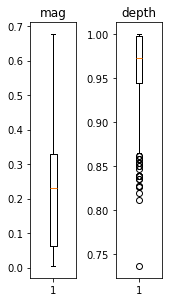

In [50]:
scaler = Normalizer()
dataScaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

plt.figure(figsize=(12, 8))
for i, column in enumerate (dataScaled.columns, 1):
    plt.subplot(2, 10, i)
    plt.boxplot(dataScaled[column])
    plt.title(column)
plt.tight_layout()
plt.show()

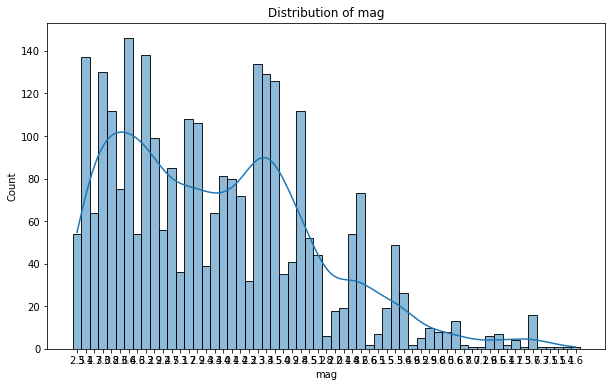

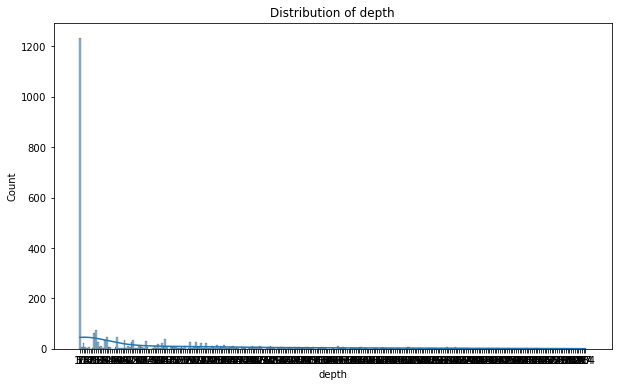

In [51]:
for column in dataScaled.columns[:6]:
    plt.figure(figsize=(10, 6))
    sns.histplot(data[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

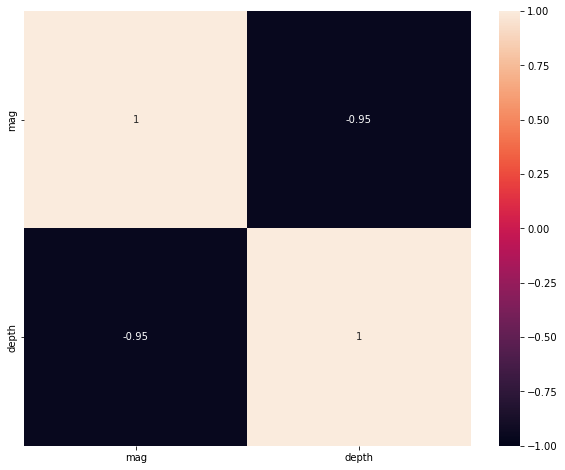

In [52]:
correlation = dataScaled.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, vmin=-1, vmax=1)
plt.show()

# Clustering

## K-Means

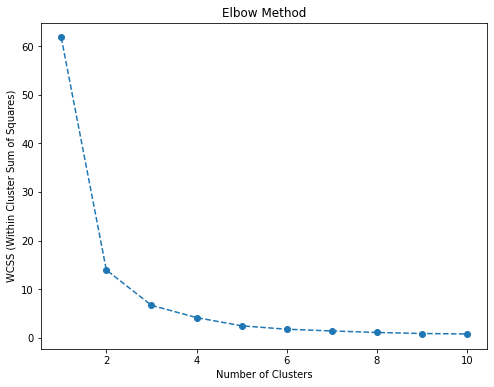

In [53]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(dataScaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within Cluster Sum of Squares)')
plt.title('Elbow Method')
plt.show()

In [54]:
cluster_knee = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
cluster_knee.elbow

3

In [55]:
kmeans = KMeans(n_clusters=cluster_knee.elbow, random_state=42)
predict_kmeans = kmeans.fit(dataScaled)
predict_kmeans.cluster_centers_

array([[0.06313876, 0.99699811],
       [0.39406792, 0.91727897],
       [0.25956044, 0.96466809]])

In [56]:
data['kmeans'] = predict_kmeans.labels_
data['kmeans'].value_counts()

/tmp/ipykernel_7428/376390094.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['kmeans'] = predict_kmeans.labels_


kmeans
0    1154
2     908
1     743
Name: count, dtype: int64

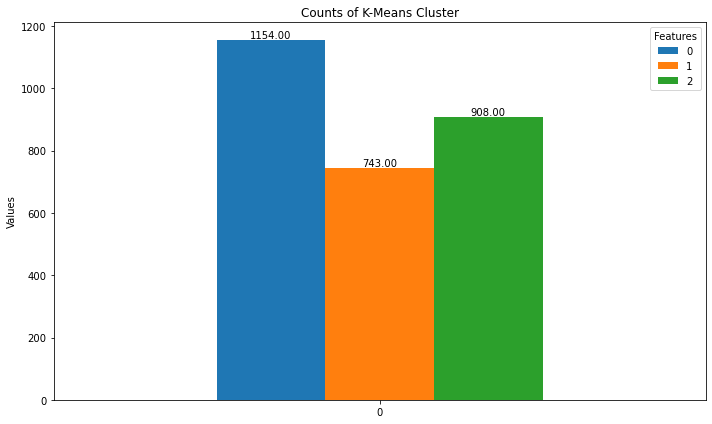

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

counts = pd.DataFrame({
    '0': [len(data[data['kmeans'] == 0])],
    '1': [len(data[data['kmeans'] == 1])],
    '2': [len(data[data['kmeans'] == 2])]
})

ax = counts.plot(kind='bar', figsize=(10, 6))

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height,
            f'{height:.2f}',
            ha='center', 
            va='bottom'
        )

plt.title('Counts of K-Means Cluster')
plt.ylabel('Values')
plt.xticks(rotation=0) 
plt.legend(title='Features')
plt.tight_layout()
plt.show()

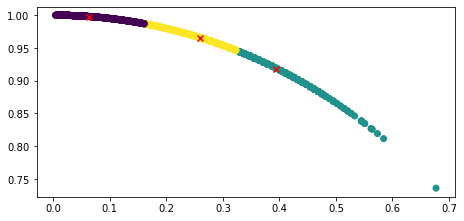

In [58]:
kmeans_data = dataScaled.to_numpy()

plt.figure(figsize=(7.5, 3.5))
plt.scatter(kmeans_data[:, 0], kmeans_data[:, 1], c=predict_kmeans.labels_, cmap='viridis')
plt.scatter(predict_kmeans.cluster_centers_[:, 0], predict_kmeans.cluster_centers_[:, 1], marker='x', color='red')
plt.show()

## K-Medoids

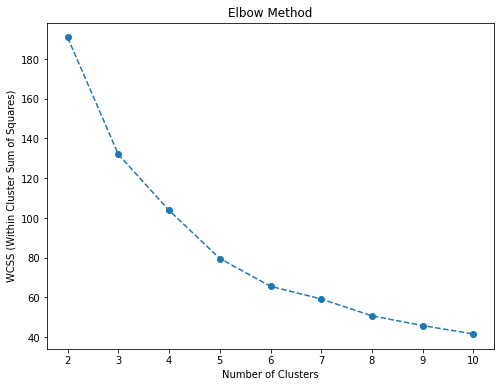

In [59]:
wcss = []

for i in range(2, 11):
    kmedoids = KMedoids(metric="manhattan", n_clusters=i, method='pam')
    kmedoids.fit(dataScaled)
    wcss.append(kmedoids.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within Cluster Sum of Squares)')
plt.title('Elbow Method')
plt.show()

In [60]:
cluster_knee = KneeLocator(range(2, 11), wcss, curve='convex', direction='decreasing')
cluster_knee.elbow

5

In [61]:
kmedoids = KMedoids(metric="manhattan", n_clusters=cluster_knee.elbow, method='pam')
predict_kmedoids = kmedoids.fit(dataScaled)
kmedoids.cluster_centers_

array([[0.03274106, 0.99946387],
       [0.34700888, 0.93786184],
       [0.43273107, 0.90152306],
       [0.13621834, 0.99067884],
       [0.26835356, 0.96332049]])

In [62]:
data['kmedoids'] = predict_kmedoids.labels_
data['kmedoids'].value_counts()

/tmp/ipykernel_7428/3650528949.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['kmedoids'] = predict_kmedoids.labels_


kmedoids
0    810
4    649
1    552
3    466
2    328
Name: count, dtype: int64

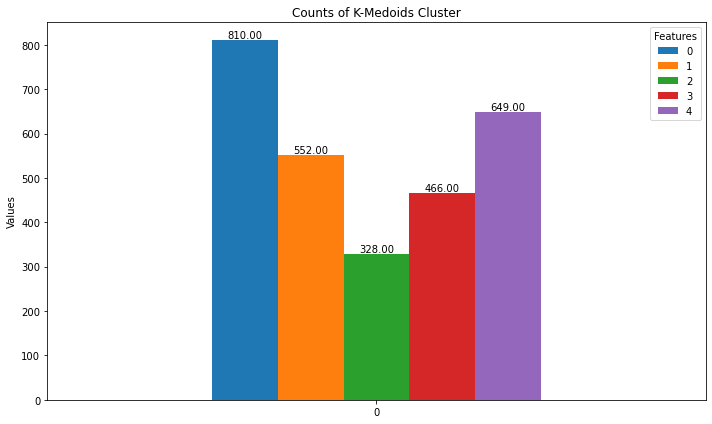

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

counts = pd.DataFrame({
    '0': [len(data[data['kmedoids'] == 0])],
    '1': [len(data[data['kmedoids'] == 1])],
    '2': [len(data[data['kmedoids'] == 2])],
    '3': [len(data[data['kmedoids'] == 3])],
    '4': [len(data[data['kmedoids'] == 4])]
})

ax = counts.plot(kind='bar', figsize=(10, 6))

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height,
            f'{height:.2f}',
            ha='center', 
            va='bottom'
        )

plt.title('Counts of K-Medoids Cluster')
plt.ylabel('Values')
plt.xticks(rotation=0) 
plt.legend(title='Features')
plt.tight_layout()
plt.show()

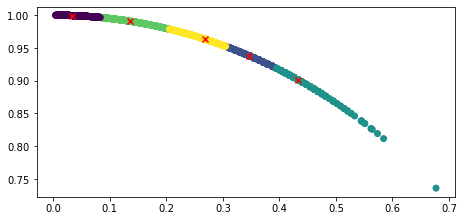

In [64]:
kmedoids_data = dataScaled.to_numpy()

plt.figure(figsize=(7.5, 3.5))
plt.scatter(kmedoids_data[:, 0], kmedoids_data[:, 1], c=predict_kmedoids.labels_, cmap='viridis')
plt.scatter(predict_kmedoids.cluster_centers_[:, 0], predict_kmedoids.cluster_centers_[:, 1], marker='x', color='red')
plt.show()

# Pengujian dan Perbandingan Silhoutte Coefficient

In [65]:
from tabulate import tabulate

avg_kmeans = silhouette_score(dataScaled, predict_kmeans.labels_)
avg_kmedoids = silhouette_score(dataScaled, predict_kmedoids.labels_)

avg = pd.DataFrame([{"K-Means": avg_kmeans, "K-Medoids": avg_kmedoids}])

print(tabulate(avg, headers='keys', tablefmt='grid', showindex=False))

+-----------+-------------+
|   K-Means |   K-Medoids |
+===========+=============+
|  0.611518 |    0.589506 |
+-----------+-------------+


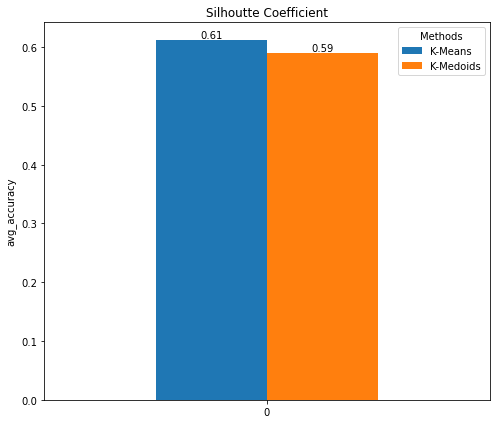

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

avg_kmeans = silhouette_score(dataScaled, predict_kmeans.labels_)
avg_kmedoids = silhouette_score(dataScaled, predict_kmedoids.labels_)

avg = pd.DataFrame([{"K-Means": avg_kmeans, "K-Medoids": avg_kmedoids}])


ax = avg.plot(kind='bar', figsize=(7, 6))

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height,
            f'{height:.2f}',
            ha='center', 
            va='bottom'
        )

plt.title('Silhoutte Coefficient')
plt.ylabel('avg_accuracy')
plt.xticks(rotation=0) 
plt.legend(title='Methods')
plt.tight_layout()
plt.show()

# Visualisasi Data K-Means

## Visualisasi Centroid K-Means

In [26]:
labels_cluster = [0, 1, 2]
labels_data = ['mag', 'depth', 'prov_enco']
centroid_kmeans = pd.DataFrame()

for index in labels_cluster:
    for label_data in labels_data:
        if label_data == 'prov_enco':
            centroid_kmeans.at[index, label_data] = data['prov_enco'][data['kmeans'] == index].value_counts().idxmax()
            
        else:
            numpy = data[label_data][data['kmeans'] == index].to_numpy()
            numpy = numpy.astype(float)
            
            if numpy.size > 0: 
                centroid_kmeans.at[index, label_data] = numpy.mean()
            else:
                centroid_kmeans.at[index, label_data] = float('nan') 

centroid_kmeans

,mag,depth,prov_enco
0,3.637576,109.426840,3.0
1,4.312113,10.028264,3.0
2,3.198899,12.267621,12.0


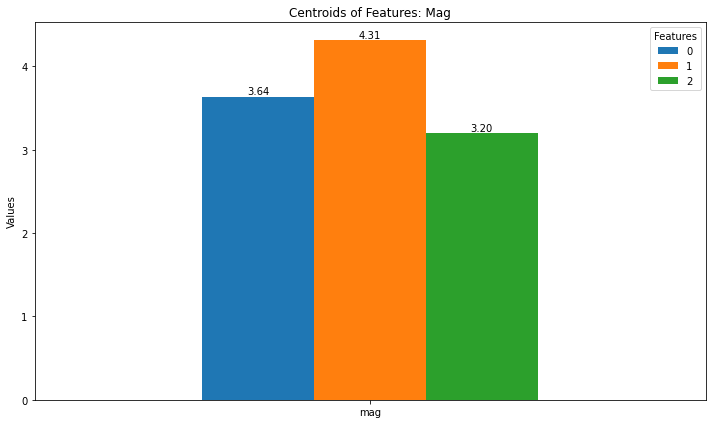

In [28]:
centroid_mag = pd.DataFrame({    
    '0': centroid_kmeans.loc[0, ['mag']],
    '1': centroid_kmeans.loc[1, ['mag']],
    '2': centroid_kmeans.loc[2, ['mag']]
})

ax = centroid_mag.plot(kind='bar', figsize=(10, 6))

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height,
            f'{height:.2f}',
            ha='center', 
            va='bottom'
        )

plt.title('Centroids of Features: Mag')
plt.ylabel('Values')
plt.xticks(rotation=0) 
plt.legend(title='Features')
plt.tight_layout()
plt.show()


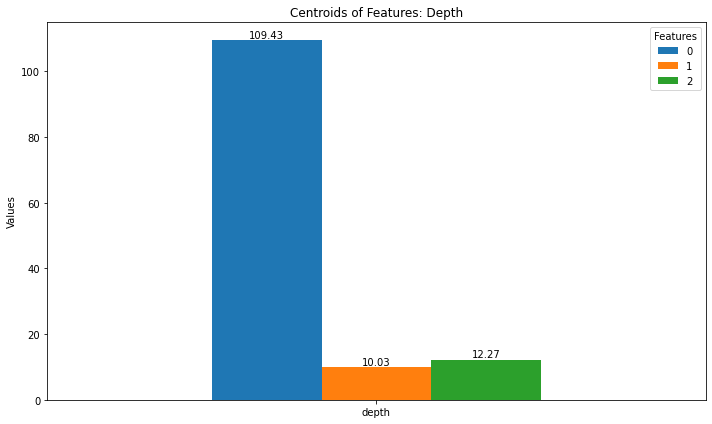

In [29]:
centroid_depth = pd.DataFrame({    
    '0': centroid_kmeans.loc[0, ['depth']],
    '1': centroid_kmeans.loc[1, ['depth']],
    '2': centroid_kmeans.loc[2, ['depth']]
})

ax = centroid_depth.plot(kind='bar', figsize=(10, 6))

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height,
            f'{height:.2f}',
            ha='center', 
            va='bottom'
        )

plt.title('Centroids of Features: Depth')
plt.ylabel('Values')
plt.xticks(rotation=0) 
plt.legend(title='Features')
plt.tight_layout()
plt.show()


In [30]:
prov = []

for i in range(3):
    counts = data["prov"][data["kmeans"] == i].value_counts().head()
    for province, count in counts.items():
        prov.append({"kmeans": i, "prov": province, "count": count})

prov_plt = pd.DataFrame(prov)
prov_plt

,kmeans,prov,count
0,0,SULUT,204
1,0,NTT,175
2,0,GORONTALO,103
3,0,NTB,76
4,0,MALUT,69
5,1,SULUT,128
6,1,MALUKUTENGGARABRT,98
7,1,MALUT,57
8,1,JATIM,55
9,1,PAPUA,51


## Visualisasi Centroid K-Medoids

In [31]:
labels_cluster = [0, 1, 2, 3, 4]
labels_data = ['mag', 'depth', 'prov_enco']
centroid_kmedoids = pd.DataFrame()

for index in labels_cluster:
    for label_data in labels_data:
        if label_data == 'prov_enco':
            centroid_kmeans.at[index, label_data] = data['prov_enco'][data['kmedoids'] == index].value_counts().idxmax()
            
        else:
            numpy = data[label_data][data['kmedoids'] == index].to_numpy()
            numpy = numpy.astype(float)
            
            if numpy.size > 0: 
                centroid_kmedoids.at[index, label_data] = numpy.mean()
            else:
                centroid_kmedoids.at[index, label_data] = float('nan') 

centroid_kmedoids

,mag,depth
0,3.721578,143.843403
1,3.764312,10.177536
2,4.879573,9.908537
3,3.402146,25.504292
4,3.124653,11.661017


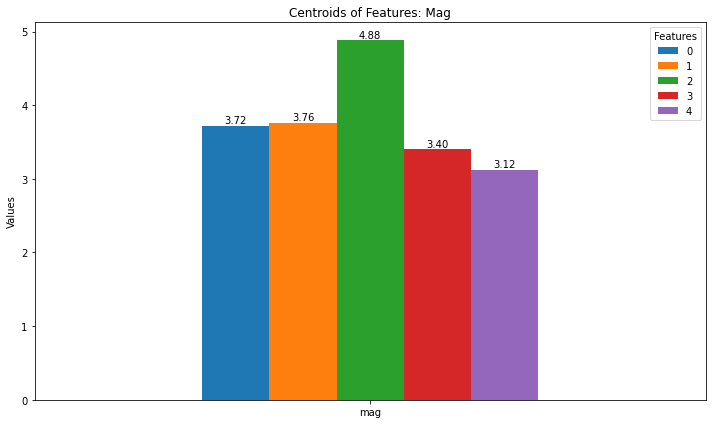

In [32]:
centroid_mag = pd.DataFrame({    
    '0': centroid_kmedoids.loc[0, ['mag']],
    '1': centroid_kmedoids.loc[1, ['mag']],
    '2': centroid_kmedoids.loc[2, ['mag']],
    '3': centroid_kmedoids.loc[3, ['mag']],
    '4': centroid_kmedoids.loc[4, ['mag']]
})

ax = centroid_mag.plot(kind='bar', figsize=(10, 6))

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height,
            f'{height:.2f}',
            ha='center', 
            va='bottom'
        )

plt.title('Centroids of Features: Mag')
plt.ylabel('Values')
plt.xticks(rotation=0) 
plt.legend(title='Features')
plt.tight_layout()
plt.show()


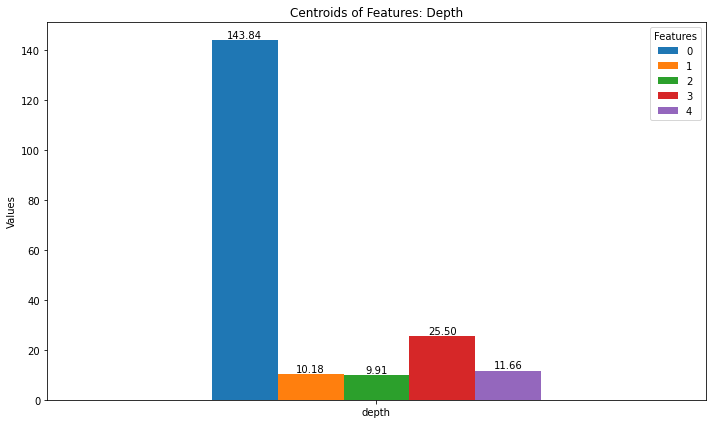

In [33]:
centroid_depth = pd.DataFrame({    
    '0': centroid_kmedoids.loc[0, ['depth']],
    '1': centroid_kmedoids.loc[1, ['depth']],
    '2': centroid_kmedoids.loc[2, ['depth']],
    '3': centroid_kmedoids.loc[3, ['depth']],
    '4': centroid_kmedoids.loc[4, ['depth']]
})

ax = centroid_depth.plot(kind='bar', figsize=(10, 6))

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height,
            f'{height:.2f}',
            ha='center', 
            va='bottom'
        )

plt.title('Centroids of Features: Depth')
plt.ylabel('Values')
plt.xticks(rotation=0) 
plt.legend(title='Features')
plt.tight_layout()
plt.show()


In [36]:
prov = []

for i in range(3):
    counts = data["prov"][data["kmedoids"] == i].value_counts().head()
    for province, count in counts.items():
        prov.append({"kmedoids": i, "prov": province, "count": count})

prov_plt = pd.DataFrame(prov)
prov_plt

,kmedoids,prov,count
0,0,SULUT,137
1,0,NTT,125
2,0,GORONTALO,92
3,0,NTB,53
4,0,MALUT,51
5,1,JATIM,57
6,1,SULUT,47
7,1,MALUKUTENGGARABRT,46
8,1,SULTENG,43
9,1,NTT,38


## Visualisasi Data Mag dan Depth secara Explicit

In [28]:
def categorize_mag(value):
    if value <= 4:
        return 'kecil'
    elif value > 4 and value <= 6:
        return 'sedang'
    elif value > 6:
        return 'besar'

def categorize_depth(value):
    if value <= 60:
        return 'dangkal'
    elif value > 60 and value <= 300:
        return 'sedang'
    elif value > 300:
        return 'dalam'

In [52]:
def plot_visual(keys, category, text, y_lim):
    x = np.arange(len(keys)) 
    width = 0.25 
    multiplier = 0
    
    fig, ax = plt.subplots(layout='constrained')
    
    for attribute, measurement in category.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3) 
        multiplier += 1
    
    ax.set_ylabel('Sum')
    ax.set_title(text)
    ax.set_xticks(x + width, labels)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, y_lim) 
    
    plt.show()

In [59]:
df = pd.DataFrame(data)

df['mag'] = df['mag'].astype(float)
df['depth'] = df['depth'].astype(float)

df['mag_category'] = df['mag'].apply(categorize_mag)
df['depth_category'] = df['depth'].apply(categorize_depth)

for cluster in range(3):
    print_cluster = pd.DataFrame()
    
    print(f"Cluster {cluster}:")
    print(df[df['kmeans'] == cluster]['mag_category'].value_counts())
    print(df[df['kmeans'] == cluster]['depth_category'].value_counts())
    cluster_df = df[df['kmeans'] == cluster]
    
    # Sort by 'mag' in descending order and select the top 10 entries
    top_cluster_df = cluster_df[['mag', 'depth', 'prov']].sort_values(by='prov', ascending=True).head(10)
    print(tabulate(top_cluster_df, headers='keys', tablefmt='grid', showindex=False))
    print("\n")

Cluster 0:
mag_category
kecil     808
sedang    334
besar      13
Name: count, dtype: int64
depth_category
sedang     613
dangkal    478
dalam       64
Name: count, dtype: int64
+-------+---------+--------+
|   mag |   depth | prov   |
+=======+=========+========+
|   2.2 |      95 | ACEH   |
+-------+---------+--------+
|   5.1 |      71 | ACEH   |
+-------+---------+--------+
|   2   |      57 | ACEH   |
+-------+---------+--------+
|   4.7 |     235 | ACEH   |
+-------+---------+--------+
|   3.1 |     126 | ACEH   |
+-------+---------+--------+
|   3.5 |      22 | ACEH   |
+-------+---------+--------+
|   5.3 |     202 | ACEH   |
+-------+---------+--------+
|   3.5 |      25 | ACEH   |
+-------+---------+--------+
|   4.5 |      74 | ACEH   |
+-------+---------+--------+
|   3.5 |      53 | ACEH   |
+-------+---------+--------+


Cluster 1:
mag_category
sedang    411
kecil     316
besar      16
Name: count, dtype: int64
depth_category
dangkal    743
Name: count, dtype: int64
+----

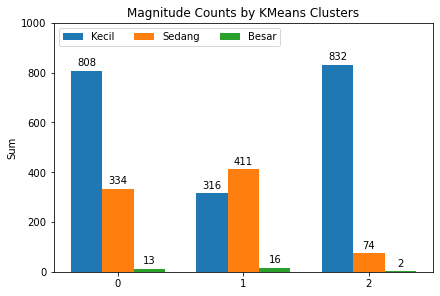

In [53]:
unique_keys = np.sort(df['kmeans'].unique())

kecil = []
sedang = []
besar = []

for i in unique_keys:
    kecil_count = df[(df['kmeans'] == i) & (df['mag_category'] == "kecil")]['mag_category'].value_counts()
    sedang_count = df[(df['kmeans'] == i) & (df['mag_category'] == "sedang")]['mag_category'].value_counts()
    besar_count = df[(df['kmeans'] == i) & (df['mag_category'] == "besar")]['mag_category'].value_counts()
    
    kecil.append(kecil_count.get("kecil", 0))
    sedang.append(sedang_count.get("sedang", 0))
    besar.append(besar_count.get("besar", 0))

labels = np.array(unique_keys)
category = {
    'Kecil': kecil,
    'Sedang': sedang,
    'Besar': besar,
}


plot_visual(labels, category, "Magnitude Counts by KMeans Clusters", 1000)

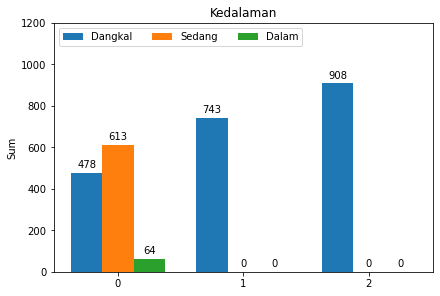

In [56]:
unique_keys = np.sort(df['kmeans'].unique())
np.array(unique_keys)

dangkal = []
sedang = []
dalam = []

for i in unique_keys:
    kecil_count = df[(df['kmeans'] == i) & (df['depth_category'] == "dangkal")]['depth_category'].value_counts()
    sedang_count = df[(df['kmeans'] == i) & (df['depth_category'] == "sedang")]['depth_category'].value_counts()
    besar_count = df[(df['kmeans'] == i) & (df['depth_category'] == "dalam")]['depth_category'].value_counts()
    
    dangkal.append(kecil_count.get("dangkal", 0))
    sedang.append(sedang_count.get("sedang", 0))
    dalam.append(besar_count.get("dalam", 0))

labels = np.array(unique_keys)
category = {
    'Dangkal': (dangkal),
    'Sedang': (sedang),
    'Dalam': (dalam),
}

plot_visual(labels, category, "Kedalaman", 1200)

# Visualisasi Data K-Medoids

## Visualisasi Centroid K-Medoids

In [32]:
labels_cluster = [0, 1, 2, 3, 4]
labels_data = ['mag', 'depth', 'prov_enco']
centroid_kmedoids = pd.DataFrame()

for index in labels_cluster:
    for label_data in labels_data:
        if label_data == 'prov_enco':
            centroid_kmedoids.at[index, label_data] = data['prov_enco'][data['kmedoids'] == index].value_counts().idxmax()
            
        else:
            numpy = data[label_data][data['kmedoids'] == index].to_numpy()
            numpy = numpy.astype(float)
            
            if numpy.size > 0: 
                centroid_kmedoids.at[index, label_data] = numpy.mean()
            else:
                centroid_kmedoids.at[index, label_data] = float('nan') 

centroid_kmedoids

,mag,depth,prov_enco
0,3.721578,143.843403,3.0
1,3.764312,10.177536,26.0
2,4.879573,9.908537,3.0
3,3.402146,25.504292,3.0
4,3.124653,11.661017,12.0


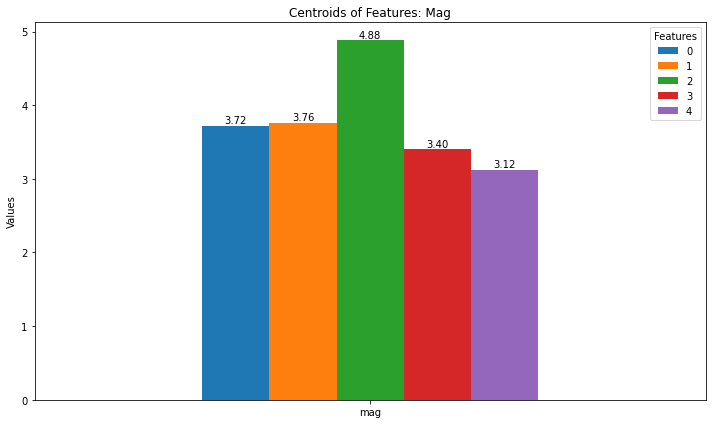

In [33]:
centroid_mag = pd.DataFrame({    
    '0': centroid_kmedoids.loc[0, ['mag']],
    '1': centroid_kmedoids.loc[1, ['mag']],
    '2': centroid_kmedoids.loc[2, ['mag']],
    '3': centroid_kmedoids.loc[3, ['mag']],
    '4': centroid_kmedoids.loc[4, ['mag']]
})

ax = centroid_mag.plot(kind='bar', figsize=(10, 6))

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height,
            f'{height:.2f}',
            ha='center', 
            va='bottom'
        )

plt.title('Centroids of Features: Mag')
plt.ylabel('Values')
plt.xticks(rotation=0) 
plt.legend(title='Features')
plt.tight_layout()
plt.show()


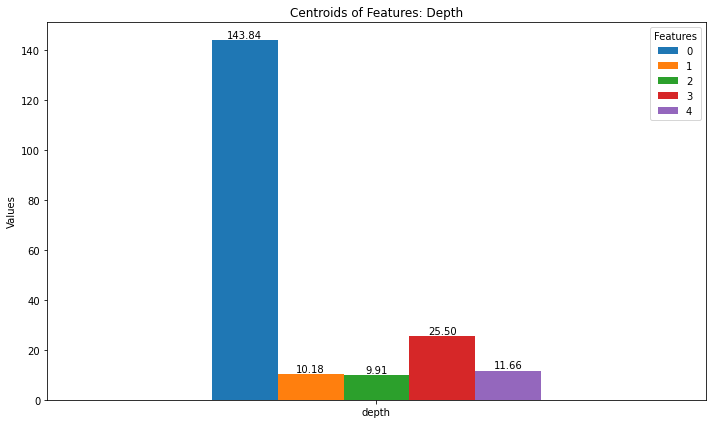

In [34]:
centroid_depth = pd.DataFrame({    
    '0': centroid_kmedoids.loc[0, ['depth']],
    '1': centroid_kmedoids.loc[1, ['depth']],
    '2': centroid_kmedoids.loc[2, ['depth']],
    '3': centroid_kmedoids.loc[3, ['depth']],
    '4': centroid_kmedoids.loc[4, ['depth']]
})

ax = centroid_depth.plot(kind='bar', figsize=(10, 6))

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height,
            f'{height:.2f}',
            ha='center', 
            va='bottom'
        )

plt.title('Centroids of Features: Depth')
plt.ylabel('Values')
plt.xticks(rotation=0) 
plt.legend(title='Features')
plt.tight_layout()
plt.show()


In [36]:
prov = []

for i in range(5):
    counts = data["prov"][data["kmedoids"] == i].value_counts().head()
    for province, count in counts.items():
        prov.append({"kmedoids": i, "prov": province, "count": count})

prov_plt = pd.DataFrame(prov)
prov_plt

,kmedoids,prov,count
0,0,SULUT,137
1,0,NTT,125
2,0,GORONTALO,92
3,0,NTB,53
4,0,MALUT,51
5,1,JATIM,57
6,1,SULUT,47
7,1,MALUKUTENGGARABRT,46
8,1,SULTENG,43
9,1,NTT,38


## Visualisasi Data K-Medoids secara Explicit

In [38]:
def categorize_mag(value):
    if value <= 4:
        return 'kecil'
    elif value > 4 and value <= 6:
        return 'sedang'
    elif value > 6:
        return 'besar'

def categorize_depth(value):
    if value <= 60:
        return 'dangkal'
    elif value > 60 and value <= 300:
        return 'sedang'
    elif value > 300:
        return 'dalam'

In [39]:
def plot_visual(keys, category, text, y_lim):
    x = np.arange(len(keys)) 
    width = 0.25 
    multiplier = 0
    
    fig, ax = plt.subplots(layout='constrained')
    
    for attribute, measurement in category.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3) 
        multiplier += 1
    
    ax.set_ylabel('Sum')
    ax.set_title(text)
    ax.set_xticks(x + width, labels)
    ax.legend(loc='upper left', ncols=3)
    ax.set_ylim(0, y_lim) 
    
    plt.show()

In [40]:
df = pd.DataFrame(data)

df['mag'] = df['mag'].astype(float)
df['depth'] = df['depth'].astype(float)

df['mag_category'] = df['mag'].apply(categorize_mag)
df['depth_category'] = df['depth'].apply(categorize_depth)

for cluster in range(5):
    print_cluster = pd.DataFrame()
    
    print(f"Cluster {cluster}:")
    print(df[df['kmedoids'] == cluster]['mag_category'].value_counts())
    print(df[df['kmedoids'] == cluster]['depth_category'].value_counts())
    cluster_df = df[df['kmedoids'] == cluster]
    
    # Sort by 'mag' in descending order and select the top 10 entries
    top_cluster_df = cluster_df[['mag', 'depth', 'prov']].sort_values(by='prov', ascending=True).head(10)
    print(tabulate(top_cluster_df, headers='keys', tablefmt='grid', showindex=False))
    print("\n")

Cluster 0:
mag_category
kecil     532
sedang    269
besar      10
Name: count, dtype: int64
depth_category
sedang     612
dangkal    135
dalam       64
Name: count, dtype: int64
+-------+---------+-----------+
|   mag |   depth | prov      |
+=======+=========+===========+
|   2   |      57 | ACEH      |
+-------+---------+-----------+
|   3.5 |      53 | ACEH      |
+-------+---------+-----------+
|   4.5 |      74 | ACEH      |
+-------+---------+-----------+
|   3.1 |     126 | ACEH      |
+-------+---------+-----------+
|   4.7 |     235 | ACEH      |
+-------+---------+-----------+
|   5.3 |     202 | ACEH      |
+-------+---------+-----------+
|   2.2 |      95 | ACEH      |
+-------+---------+-----------+
|   5.1 |      71 | ACEH      |
+-------+---------+-----------+
|   2.6 |      55 | ACEHBARAT |
+-------+---------+-----------+
|   3   |      57 | ACEHBESAR |
+-------+---------+-----------+


Cluster 1:
mag_category
kecil     437
sedang    115
Name: count, dtype: int64
depth_

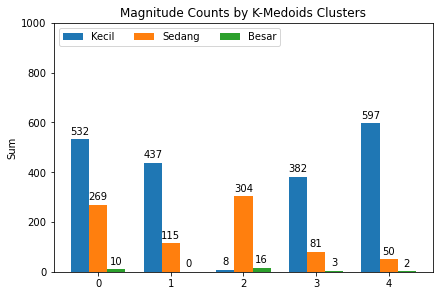

In [41]:
unique_keys = np.sort(df['kmedoids'].unique())

kecil = []
sedang = []
besar = []

for i in unique_keys:
    kecil_count = df[(df['kmedoids'] == i) & (df['mag_category'] == "kecil")]['mag_category'].value_counts()
    sedang_count = df[(df['kmedoids'] == i) & (df['mag_category'] == "sedang")]['mag_category'].value_counts()
    besar_count = df[(df['kmedoids'] == i) & (df['mag_category'] == "besar")]['mag_category'].value_counts()
    
    kecil.append(kecil_count.get("kecil", 0))
    sedang.append(sedang_count.get("sedang", 0))
    besar.append(besar_count.get("besar", 0))

labels = np.array(unique_keys)
category = {
    'Kecil': kecil,
    'Sedang': sedang,
    'Besar': besar,
}


plot_visual(labels, category, "Magnitude Counts by K-Medoids Clusters", 1000)

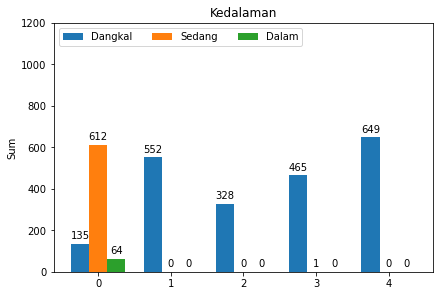

In [42]:
unique_keys = np.sort(df['kmedoids'].unique())
np.array(unique_keys)

dangkal = []
sedang = []
dalam = []

for i in unique_keys:
    kecil_count = df[(df['kmedoids'] == i) & (df['depth_category'] == "dangkal")]['depth_category'].value_counts()
    sedang_count = df[(df['kmedoids'] == i) & (df['depth_category'] == "sedang")]['depth_category'].value_counts()
    besar_count = df[(df['kmedoids'] == i) & (df['depth_category'] == "dalam")]['depth_category'].value_counts()
    
    dangkal.append(kecil_count.get("dangkal", 0))
    sedang.append(sedang_count.get("sedang", 0))
    dalam.append(besar_count.get("dalam", 0))

labels = np.array(unique_keys)
category = {
    'Dangkal': (dangkal),
    'Sedang': (sedang),
    'Dalam': (dalam),
}

plot_visual(labels, category, "Kedalaman", 1200)

# Export Model

In [195]:
## KMeans Model
with open('kmeans_model.pkl', 'wb') as file:
    pickle.dump(kmeans, file)
    
print("Model saved to kmeans_model.pkl")

Model saved to kmeans_model.pkl


In [29]:
with open('kmedoids_model.pkl', 'wb') as file:
    pickle.dump(kmedoids, file)
    
print("Model saved to kmedoids_model.pkl")

Model saved to kmedoids_model.pkl


In [67]:
data.to_csv('dataset.csv', index=False)

In [73]:
data

,date,mag,depth,prov,kmeans,kmedoids
0,Nov,2.5,10,Maluku,2,4
1,Nov,3.1,10,Maluku,2,4
2,Nov,4.7,51,Papua,0,3
3,Nov,3.0,26,Sulawesi Utara,0,3
4,Nov,3.8,132,Sulawesi Utara,0,0
...,...,...,...,...,...,...
1311,Apr,2.9,10,Sulawesi Tengah,2,4
1312,Apr,3.7,10,Jawa Timur,1,1
1313,Apr,3.0,10,Sulawesi Selatan,2,4
1314,Apr,3.6,10,Jawa Timur,1,1


In [86]:
change = data.to_dict(orient='records')
change

[{'date': 'Nov',
  'mag': '2.5',
  'depth': '10',
  'prov': 'Maluku',
  'kmeans': 2,
  'kmedoids': 4},
 {'date': 'Nov',
  'mag': '3.1',
  'depth': '10',
  'prov': 'Maluku',
  'kmeans': 2,
  'kmedoids': 4},
 {'date': 'Nov',
  'mag': '4.7',
  'depth': '51',
  'prov': 'Papua',
  'kmeans': 0,
  'kmedoids': 3},
 {'date': 'Nov',
  'mag': '3.0',
  'depth': '26',
  'prov': 'Sulawesi Utara',
  'kmeans': 0,
  'kmedoids': 3},
 {'date': 'Nov',
  'mag': '3.8',
  'depth': '132',
  'prov': 'Sulawesi Utara',
  'kmeans': 0,
  'kmedoids': 0},
 {'date': 'Nov',
  'mag': '2.6',
  'depth': '188',
  'prov': 'Nusa Tenggara Barat',
  'kmeans': 0,
  'kmedoids': 0},
 {'date': 'Nov',
  'mag': '3.6',
  'depth': '10',
  'prov': 'Maluku',
  'kmeans': 1,
  'kmedoids': 1},
 {'date': 'Nov',
  'mag': '4.6',
  'depth': '10',
  'prov': 'Maluku Utara',
  'kmeans': 1,
  'kmedoids': 2},
 {'date': 'Nov',
  'mag': '3.8',
  'depth': '10',
  'prov': 'Sulawesi Selatan',
  'kmeans': 1,
  'kmedoids': 1},
 {'date': 'Nov',
  'mag': '

'[{"date": "Nov", "mag": "2.5", "depth": "10", "prov": "Maluku", "kmeans": 2, "kmedoids": 4}, {"date": "Nov", "mag": "3.1", "depth": "10", "prov": "Maluku", "kmeans": 2, "kmedoids": 4}, {"date": "Nov", "mag": "4.7", "depth": "51", "prov": "Papua", "kmeans": 0, "kmedoids": 3}, {"date": "Nov", "mag": "3.0", "depth": "26", "prov": "Sulawesi Utara", "kmeans": 0, "kmedoids": 3}, {"date": "Nov", "mag": "3.8", "depth": "132", "prov": "Sulawesi Utara", "kmeans": 0, "kmedoids": 0}, {"date": "Nov", "mag": "2.6", "depth": "188", "prov": "Nusa Tenggara Barat", "kmeans": 0, "kmedoids": 0}, {"date": "Nov", "mag": "3.6", "depth": "10", "prov": "Maluku", "kmeans": 1, "kmedoids": 1}, {"date": "Nov", "mag": "4.6", "depth": "10", "prov": "Maluku Utara", "kmeans": 1, "kmedoids": 2}, {"date": "Nov", "mag": "3.8", "depth": "10", "prov": "Sulawesi Selatan", "kmeans": 1, "kmedoids": 1}, {"date": "Nov", "mag": "3.2", "depth": "42", "prov": "Sulawesi Utara", "kmeans": 0, "kmedoids": 0}, {"date": "Nov", "mag": "